In [1]:
# Importing all necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Loading Dataser

df = pd.read_excel("/content/Suha - Data for AoT Sentiment Analysis.xlsx")
df.head(5)

,review_text,score,date
0,There’s a current trend that favors dark and e...,3,2014-12-25 00:00:00
1,"Shingeki no Kyojin, the anime that has brought...",3,2014-02-17 00:00:00
2,The fact that so many bloggers still name Shin...,4,2014-08-01 00:00:00
3,"""I'm going to kill all the Titans!""\n\nWhy, of...",2,2014-09-02 00:00:00
4,I always looked at AOT as a joke because despi...,1,2025-10-13 00:00:00


In [3]:
# Checking Dataset Properties
df.shape

(100, 3)

<Axes: xlabel='score'>

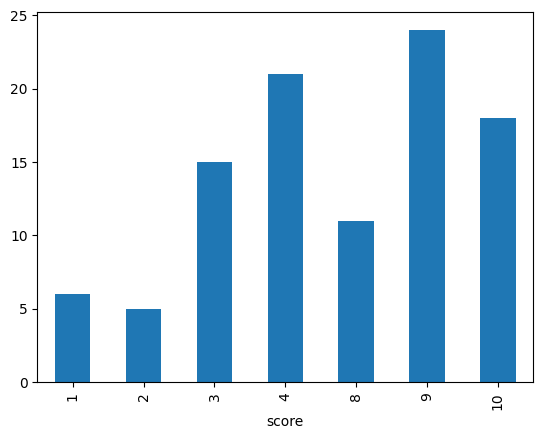

In [4]:
# Checking Score Distribution
df['score'].value_counts().sort_index().plot(kind='bar')

In [5]:
#Sentiment Mapping the score
sentiment_mapping = {
    1 : "negative",
    2 : "negative",
    3 : "negative",
    4 : "negative",
    8 : "positive",
    9 : "positive",
    10 : "positive"
}

df["label"] = df["score"].map(sentiment_mapping)
df["label"].value_counts()

,count
label,
positive,53
negative,47


In [6]:
# Text Preprocessing
import re

def preprocess_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['clean_text'] = df['review_text'].apply(preprocess_text)
df['clean_text'].head(5)

,clean_text
0,theres a current trend that favors dark and ed...
1,shingeki no kyojin the anime that has brought ...
2,the fact that so many bloggers still name shin...
3,im going to kill all the titans why of course ...
4,i always looked at aot as a joke because despi...


In [7]:
# TF - IDF Vectorization
# Using english stop words
tfidf = TfidfVectorizer(stop_words= "english")

# Learning dataset words and converting into numbers
x = tfidf.fit_transform(df['clean_text'])

x.shape

(100, 5897)

In [8]:
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.linear_model import LogisticRegression # Import LogisticRegression

# Initialize the Logistic Regression model
lr = LogisticRegression(max_iter=1000)

# 5-fold cross validation
cv_scores = cross_val_score(lr, x, df["label"], cv=5, scoring="accuracy")

print("Cross-validation accuracy scores:", cv_scores)
print("Average CV accuracy:", np.mean(cv_scores))
print("Standard deviation:", np.std(cv_scores))

Cross-validation accuracy scores: [0.7  0.6  0.75 0.7  0.8 ]
Average CV accuracy: 0.71
Standard deviation: 0.06633249580710802


In [9]:
# Creating the Training and test dataset
X_train, X_test, y_train, y_test = train_test_split(
    x,
    df["label"],
    test_size = 0.2,
    random_state = 42,
    stratify = df["label"])

print(X_train.shape)
print(X_test.shape)

(80, 5897)
(20, 5897)


In [10]:
# Logistic Regression
lr = LogisticRegression(max_iter= 1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [11]:
y_pred = lr.predict(X_test)

print("Accuracy", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy 0.75
              precision    recall  f1-score   support

    negative       0.83      0.56      0.67         9
    positive       0.71      0.91      0.80        11

    accuracy                           0.75        20
   macro avg       0.77      0.73      0.73        20
weighted avg       0.77      0.75      0.74        20

[[ 5  4]
 [ 1 10]]


In [12]:
# Naive Bayes

nb = MultinomialNB()
nb.fit(X_train, y_train)

MultinomialNB()

In [13]:
y_pred_nb = nb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))
print(confusion_matrix(y_test, y_pred_nb))

Accuracy: 0.6
              precision    recall  f1-score   support

    negative       1.00      0.11      0.20         9
    positive       0.58      1.00      0.73        11

    accuracy                           0.60        20
   macro avg       0.79      0.56      0.47        20
weighted avg       0.77      0.60      0.49        20

[[ 1  8]
 [ 0 11]]


In [14]:
#Sentiment Scoring

feature_names = tfidf.get_feature_names_out()

coefficents = lr.coef_[0]

In [15]:
word_scores = pd.DataFrame({'word': feature_names, 'score': coefficents})
word_scores.head(10)

,word,score
0,aahh,0.012061
1,abandon,0.029320
2,abilities,-0.033786
3,ability,-0.036918
4,able,0.047722
5,abnormal,0.000865
6,abruptly,-0.016518
7,abs,-0.023714
8,absolute,-0.007863
9,absolutely,-0.103220


In [16]:
# Most Negative Words
negative_words = word_scores.sort_values(by='score').head(15)
negative_words

,word,score
3600,okay,-0.376098
4190,really,-0.316913
2255,good,-0.313783
3061,liked,-0.300257
559,boring,-0.253461
5837,worst,-0.227995
551,boom,-0.222360
391,bad,-0.220018
5827,worldbuilding,-0.219302
5257,terrible,-0.216209


In [17]:
positive_words = word_scores.sort_values(by='score', ascending=False).head(15)
positive_words

,word,score
5346,titans,0.399147
1691,episode,0.367342
4997,story,0.363267
5826,world,0.362264
2550,humanity,0.361677
777,characters,0.304572
45,action,0.296128
2852,ive,0.279695
1688,epic,0.276896
2556,humans,0.272579


In [18]:
word_scores_dict = dict(zip(word_scores['word'], word_scores['score']))

In [19]:
from wordcloud import WordCloud
positive_words_dict = dict(zip(positive_words['word'], positive_words['score']))

wordcloud_pos = WordCloud(width=800, height=400,
                        background_color='white',
                        colormap='viridis'
                        ).generate_from_frequencies(positive_words_dict)

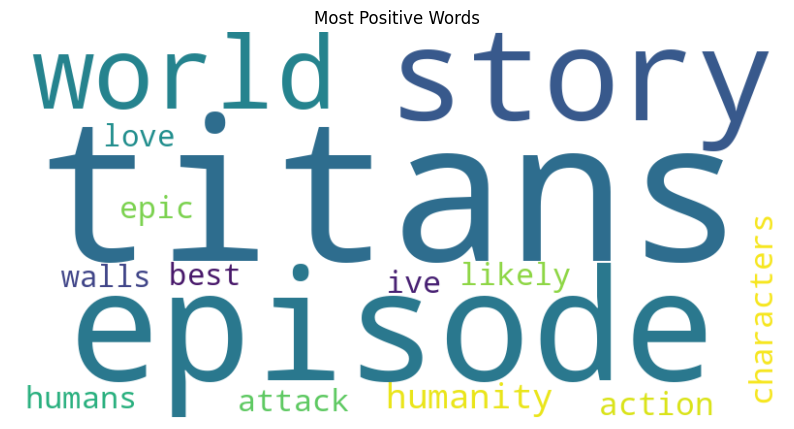

In [20]:
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Most Positive Words')
plt.show()

In [21]:
negative_dict = dict(zip(negative_words['word'], abs(negative_words['score'])))

In [22]:
wordcloud_neg = WordCloud(width=800, height=400,
                        background_color='white',
                        colormap='magma'
                          ).generate_from_frequencies(negative_dict)

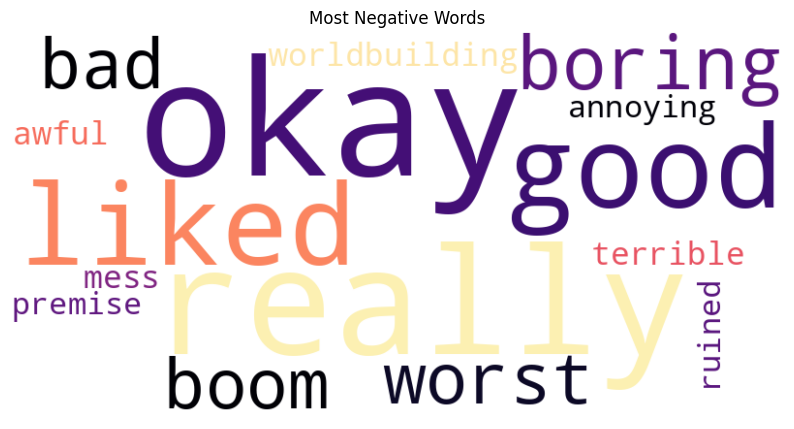

In [23]:
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Most Negative Words')
plt.show()

In [24]:
# Error Analysis
df_test = pd.DataFrame({'review' : df.loc[y_test.index, "review_text"],
                        'actual_label' : y_test,
                        'predicted_label' : y_pred})

In [25]:
errors = df_test[df_test["actual_label"] != df_test["predicted_label"]]
errors

,review,actual_label,predicted_label
74,Watching this show makes me crave POTATOES!\nH...,positive,negative
42,"Of course, like most modern anime, Attack on T...",negative,positive
14,Shingeki no Kyojin was one of the top rated an...,negative,positive
20,Story 2/10\nIn terms of story the only thing t...,negative,positive
22,"After finished this series, there are a couple...",negative,positive
